# Import Libraries

In [1]:
# Analisi dati e Visualizzazione
import pandas as pd

# Scikit-learn: Preprocessing e Dimensionality Reduction
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC

# Scikit-learn: Model Selection e Pipeline
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline

# Our packages
from support_modules.utils import *
from support_modules.plot import *

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


from sklearn.compose import make_column_selector
from sklearn import set_config
set_config(transform_output="pandas")



# Global Variables

In [2]:
SEED = 42
FILENAME = "../data/train.csv"

# Load the dataset

In [3]:
df = pd.read_csv(FILENAME, encoding='ISO-8859-1', sep=",")

rows = df.shape[0]
cols = df.shape[1]
print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")

# Righe: 148301 # Colonne: 145



# Preprocessing

## 1. Remove duplicates rows and columns

In [4]:
# Individua se esistono colonne con lo stesso nome
# Se esistono, allora se le colonne sono duplicati perfetti, droppiamo il duplicato
# Se esistono, ma nono sono perfetti duplicati, per intervenire consciamente sarebbe necessario avere maggior domain knowledge
feature_list = df.columns.to_list()
has_duplicate_cols = len(feature_list) != len(set(feature_list))
print("Ci sono colonne con lo stesso nome?", has_duplicate_cols)

if has_duplicate_cols:
    df2 = df.T.drop_duplicates().T


# Rimuovi righe duplicate
df.drop_duplicates(inplace=True)


##################################################
print("Nuovo # Righe: " + str(rows)+ " Nuovo # Colonne: "+str(cols) + "\n")


Ci sono colonne con lo stesso nome? False
Nuovo # Righe: 148301 Nuovo # Colonne: 145



## 2. Label extraction and train-test splitting

In [5]:
X = df.drop(columns=["grade"])
y = df["grade"]

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

In [7]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)

## 3. Pipeline

In [8]:
from support_modules.preprocessing import *

In [9]:
from support_modules.constants import *

In [10]:
remainder_pipeline = Pipeline([
    ('impute_median', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('impute_unknown', SimpleImputer(strategy='constant', fill_value='Unknown'), categorical_to_unknown_cols),
        ('impute_0', SimpleImputer(strategy='constant', fill_value=0), fill_zero_cols),
        ('impute_10k', SimpleImputer(strategy='constant', fill_value=999), fill_big_cols),
        ('impute_mode_cat',SimpleImputer(strategy='most_frequent'), fill_to_mode_cat),
        ('impute_mode_num', SimpleImputer(strategy='most_frequent'), fill_to_mode_num),
    ],
    remainder=remainder_pipeline,
    verbose_feature_names_out=False
)


encoding = ColumnTransformer(
    transformers=[
        # Applica categorical_pipe a TUTTE le colonne di tipo object o category
        ('cat_step', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), make_column_selector(dtype_include=['object'])),
    ], 
    # Tutto ciò che è numerico e non è stato toccato sopra, viene scalato qui
    remainder="passthrough", 
    verbose_feature_names_out=False
)

In [11]:
# Usa memory per cachare i risultati
from joblib import Memory
memory = Memory(location='cache_dir', verbose=0)

In [ ]:
full_pipeline = Pipeline([
    ('drop_leakage', ColumnDropper(columns = loan_performance_data_leakage + settlement_data_leakage + hardship_data_leakage + other_leakage + loan_contract_interest_rate)),
    ('drop_non_significant', ColumnDropper(columns = other_non_significant)),
    ('drop_high_nan', HighNanDropper(threshold=0.9)),
    ('drop_joint_and_secondary', ColumnDropper(columns = joint_and_secondary_cols)),
    ('high_correlation', HighlyCorrelatedDropper(threshold=0.95)),
    ('feature_extraction', NumericExtractor(columns = number_from_string_cols)),
    ('fico_average', FeatureAverager(columns = average_cols, new_name='fico_average')),
    ('date_diff', DateDifferenceTransformer(reference_col=date_diff_reference, target_cols=date_diff_target)),
    ('rounding_int', RoundToIntTransformer(columns = round_to_nearest_int)),

    ('preprocessor', preprocessor),
    ('encoding', encoding),

    ('winsorizer', Winsorizer(lower_quantile=0.01, upper_quantile=0.99)),
    ('skewness', SkewnessTransformer(threshold=0.75)),
    ('scaler', MinMaxScaler()),
    ('lda', LDA(n_components=6)),
    ('clf', SVC(kernel='rbf', class_weight='balanced', max_iter=20000, random_state=SEED))
], memory=memory)

# probability=True rimosso: predict() usa solo le label, quindi il Platt scaling (CV interna
# a 5 fold) era puro spreco -> ~5x piu' veloce. max_iter alzato per favorire la convergenza.
# RBF-SVM e' O(n^2): nella run precedente ~22 min/fit su tutti i dati. Si esegue la search
# (e il refit del best) su un sottocampione stratificato da 40k righe per restare nel budget ~3h.
param_grid_svc = {
    'scaler':      [StandardScaler(), MinMaxScaler()],
    'clf__C':      [1, 10, 50, 100],
    'clf__gamma':  ['scale', 0.1, 1],
    'clf__kernel': ['rbf'],
}
# 2*4*3 = 24 combinazioni x cv=3 = 72 fit (sul sottocampione)

X_search, _, y_search, _ = train_test_split(
    X_train, y_train, train_size=40000, stratify=y_train, random_state=SEED
)

grid = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid_svc,
    cv=3,
    scoring='balanced_accuracy',
    error_score='raise',
    n_jobs=-1,
    verbose=3
)
grid.fit(X_search, y_search)

In [13]:
memory.clear(warn=False)

In [14]:
import pickle

# 1. Recuperiamo il miglior stimatore
full_best_pipeline = grid.best_estimator_

print("Migliori parametri:", grid.best_params_)
print(f"Miglior CV Score: {grid.best_score_:.4f}")

# 2. Dividiamo la Pipeline
# [:-1] prende tutto tranne l'ultimo step ('clf')
preprocessing_part = full_best_pipeline[:-1] 
# Accediamo al classificatore tramite il suo nome 'clf'
classifier_part = full_best_pipeline.named_steps['clf']

# 3. Salvataggio (Uso .pkl o .joblib per convenzione)
try:
    with open("svc_preprocessor.save", "wb") as f:
        pickle.dump(preprocessing_part, f)

    with open("svc.save", "wb") as f:
        pickle.dump(classifier_part, f)
        
    print("\nFile salvati correttamente:")
    print("- 'svc_preprocessor.save' (Contiene tutti i drop e le trasformazioni)")
    print("- 'svc.save' (Contiene solo il SVC allenato)")
except Exception as e:
    print(f"Errore durante il salvataggio: {e}")

Migliori parametri: {'clf__C': 5, 'clf__kernel': 'rbf', 'clf__max_iter': 3000, 'scaler': StandardScaler()}
Miglior CV Score: 0.2914

File salvati correttamente:
- 'svc_preprocessor.save' (Contiene tutti i drop e le trasformazioni)
- 'svc.save' (Contiene solo il SVC allenato)


REPORT VALUTAZIONE: SVC
Workflow rilevato: Preprocessor (Custom Pipeline)
Parametri SVC: C=5, kernel='rbf', max_iter=3000
----------------------------------------

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.43      0.66      0.52      6634
           1       0.19      0.01      0.03      9435
           2       0.35      0.01      0.01      9270
           3       0.11      0.19      0.14      5314
           4       0.13      0.21      0.16      3021
           5       0.07      0.15      0.09      1881
           6       0.10      0.46      0.16      1521

    accuracy                           0.20     37076
   macro avg       0.19      0.24      0.16     37076
weighted avg       0.24      0.20      0.15     37076

Accuracy Score:          0.1950
Balanced Accuracy Score: 0.2425


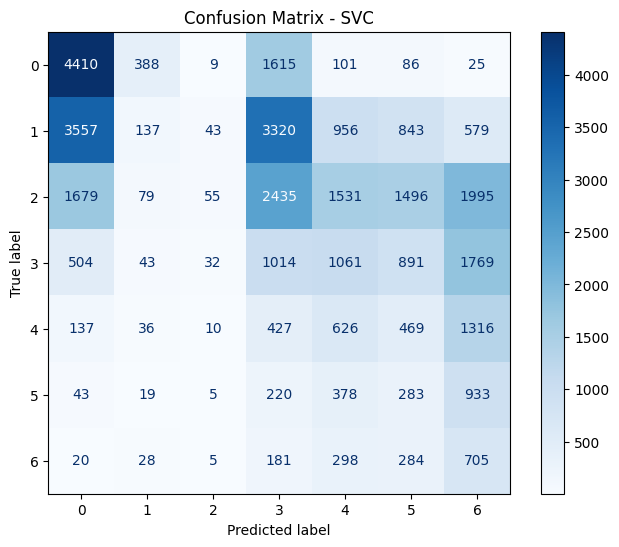

In [15]:
evaluate_model(X_val, y_val, "svc")